## Loading the dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import mailbox

mboxfile = "/Users/grindhardt/Desktop/GMAIL DATA/All mail Including Spam and Trash-002.mbox"
mbox = mailbox.mbox(mboxfile)
mbox

In [3]:
for key in mbox[0].keys():
    print(key)

X-GM-THRID
X-Gmail-Labels
Delivered-To
Received
X-Received
ARC-Seal
ARC-Message-Signature
ARC-Authentication-Results
Return-Path
Received
Received-SPF
Authentication-Results
DKIM-Signature
X-Google-DKIM-Signature
X-Gm-Message-State
MIME-Version
X-Received
Date
X-Account-Notification-Type
Feedback-ID
gmsai
X-Google-Notification-Metadata
X-Notifications
X-Notifications-Bounce-Info
Message-ID
Subject
From
To
Content-Type


## Data transformation

In [4]:
import csv

with open('mailbox.csv', 'w') as outputfile:
    writer = csv.writer(outputfile)
    writer.writerow(['subject', 'from', 'date', 'to', 'label', 'thread'])
    for message in mbox:
        writer.writerow([
            message['subject'], message['from'], message['date'], message['to'], message['X-Gmail-Labels'], message['X-GM-THRID']])

In [5]:
dfs = pd.read_csv('mailbox.csv', names=['subject', 'from', 'date', 'to', 'label', 'thread'])

In [6]:
dfs.dtypes

subject    str
from       str
date       str
to         str
label      str
thread     str
dtype: object

In [7]:
dfs['date'] = dfs['date'].apply(lambda x: pd.to_datetime(x, errors='coerce', utc=True))

In [8]:
dfs = dfs[dfs['date'].notna()]

In [9]:
dfs.to_csv('gmail.csv')

In [10]:
dfs.info()

<class 'pandas.DataFrame'>
Index: 70287 entries, 1 to 71683
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype              
---  ------   --------------  -----              
 0   subject  70272 non-null  str                
 1   from     70287 non-null  str                
 2   date     70287 non-null  datetime64[us, UTC]
 3   to       70251 non-null  str                
 4   label    70284 non-null  str                
 5   thread   70287 non-null  str                
dtypes: datetime64[us, UTC](1), str(5)
memory usage: 3.8 MB


In [11]:
dfs.head(10)

,subject,from,date,to,label,thread
1,Archive of Google data requested,Google Takeout <no-reply@accounts.google.com>,2026-09-17 20:55:24+00:00,dragonoids.2004@gmail.com,"Inbox,Important,Category Updates,Unread",1876613949275959936
2,Do you know the difference between you and Mag...,"""Chess.com"" <hello@chess.com>",2026-09-16 01:59:24+00:00,dragonoids.2004@gmail.com,"Inbox,Category Promotions,Unread",1876451881059910485
3,A Nashville home for you at $535K.,Redfin <listings@redfin.com>,2026-09-17 15:49:11+00:00,dragonoids.2004@gmail.com,"Inbox,Important,Category Updates,Unread",1876594683408385775
4,You're so close to hitting a 2-week streak.,Quizlet <newsletter@lifecycle.quizlet.com>,2026-09-16 13:01:34+00:00,dragonoids.2004@gmail.com,"Inbox,Category Updates,Unread",1876493542377749665
5,"Ty, get 25% off select styles when you spend $...","""New Balance Offers"" <newbalance@email.newbala...",2026-09-16 05:54:33+00:00,dragonoids.2004@gmail.com,"Inbox,Category Promotions,Unread",1876466676114685014
6,Back In Your Rotation,boohooMAN <style@e.boohooman.com>,2026-09-15 22:16:54+00:00,dragonoids.2004@gmail.com,"Inbox,Category Promotions,Unread",1876437881916376326
7,=?UTF-8?B?V2XigJl2ZQ==?= been in the lab =?UTF...,Etsy <email@email.etsy.com>,2026-09-16 15:13:25+00:00,dragonoids.2004@gmail.com,"Inbox,Category Promotions,Unread",1876501835353200092
8,"Your Request: $1,250 Scholarship!",New Scholarships | Fastweb <webmaster@fastweb....,2026-09-16 13:46:05+00:00,dragonoids.2004@gmail.com,"Inbox,Category Updates,Unread",1876496342393271275
9,Small-shop treasures await =?UTF-8?B?8J+qjg==?=,Etsy <email@email.etsy.com>,2026-09-17 18:15:13+00:00,dragonoids.2004@gmail.com,"Inbox,Important,Category Promotions,Unread",1876603872921884216
10,Your Wednesday just got way better,Pizza Hut <Promotions@my.pizzahut.com>,2026-09-16 18:20:46+00:00,dragonoids.2004@gmail.com,"Inbox,Category Promotions,Unread",1876513624600360164


In [12]:
dfs.columns

Index(['subject', 'from', 'date', 'to', 'label', 'thread'], dtype='str')

## Data refactoring

In [13]:
import re

def extract_email_ID(string):
    email = re.findall(r'<(.+?)>', string)
    if not email:
        email = list(filter(lambda y: '@' in y, string.split()))
    return email[0] if email else np.nan

In [14]:
dfs['from'] = dfs['from'].apply(lambda x: extract_email_ID(x))

In [15]:
myemail = 'dragonoids.2004@gmail.com'
dfs['label'] = dfs['from'].apply(lambda x: 'sent' if x == myemail else 'inbox')

In [16]:
dfs.drop(columns='to', inplace=True)

In [17]:
dfs.head(10)

,subject,from,date,label,thread
1,Archive of Google data requested,no-reply@accounts.google.com,2026-09-17 20:55:24+00:00,inbox,1876613949275959936
2,Do you know the difference between you and Mag...,hello@chess.com,2026-09-16 01:59:24+00:00,inbox,1876451881059910485
3,A Nashville home for you at $535K.,listings@redfin.com,2026-09-17 15:49:11+00:00,inbox,1876594683408385775
4,You're so close to hitting a 2-week streak.,newsletter@lifecycle.quizlet.com,2026-09-16 13:01:34+00:00,inbox,1876493542377749665
5,"Ty, get 25% off select styles when you spend $...",newbalance@email.newbalance.com,2026-09-16 05:54:33+00:00,inbox,1876466676114685014
6,Back In Your Rotation,style@e.boohooman.com,2026-09-15 22:16:54+00:00,inbox,1876437881916376326
7,=?UTF-8?B?V2XigJl2ZQ==?= been in the lab =?UTF...,email@email.etsy.com,2026-09-16 15:13:25+00:00,inbox,1876501835353200092
8,"Your Request: $1,250 Scholarship!",webmaster@fastweb.com,2026-09-16 13:46:05+00:00,inbox,1876496342393271275
9,Small-shop treasures await =?UTF-8?B?8J+qjg==?=,email@email.etsy.com,2026-09-17 18:15:13+00:00,inbox,1876603872921884216
10,Your Wednesday just got way better,Promotions@my.pizzahut.com,2026-09-16 18:20:46+00:00,inbox,1876513624600360164


## Refactoring Timezones

In [18]:
import datetime
import pytz

def refactor_timezone(x):
    est = pytz.timezone('US/Eastern')
    return x.astimezone(est)

In [19]:
dfs['date'] = dfs['date'].apply(lambda x: refactor_timezone(x))

In [20]:
dfs['dayofweek'] = dfs['date'].apply(lambda x: x.weekday_name)
dfs['dayofweek'] = pd.Categorical(dfs['dayofweek'], categories=[
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], ordered=True)

#weekday_name is no longer apart of pandas library. Using it throws error in code and doesn't allow my visualizations to show for dates and times. Switched to using dt.day_name() method. 

AttributeError: 'Timestamp' object has no attribute 'weekday_name'

In [21]:
dfs['dayofweek'] = dfs['date'].dt.day_name()
dfs['dayofweek'] = pd.Categorical(dfs['dayofweek'], categories=[
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], ordered=True)

In [22]:
dfs['timeofday'] = dfs['date'].apply(lambda x: x.hour + x.minute/60 + x.second/3600)

In [23]:
dfs['hour'] = dfs['date'].apply(lambda x: x.hour)

In [24]:
dfs['year_int'] = dfs['date'].apply(lambda x: x.year)

In [25]:
dfs['year'] = dfs['date'].apply(lambda x: x.year + x.dayofyear/365.25)

In [26]:
dfs.index = dfs['date']
del dfs['date']

## Number of emails

In [27]:
print(dfs.index.min().strftime('%a, %d %b %Y %I:%M %p'))
print(dfs.index.max().strftime('%a, %d %b %Y %I:%M %p'))

print(dfs['label'].value_counts())

Wed, 28 Sep 2016 03:13 PM
Thu, 17 Sep 2026 04:55 PM
label
inbox    70149
sent       138
Name: count, dtype: int64


## Time of day

In [28]:
sent = dfs[dfs['label']=='sent']
received = dfs[dfs['label']=='inbox']

In [29]:
from matplotlib.ticker import MaxNLocator

In [30]:
def plot_todo_vs_year(df, ax, color='C0', s=0.5, title=''):
  ind = np.zeros(len(df), dtype='bool')
  est = pytz.timezone('US/Eastern')
    
  df[~ind].plot.scatter('year', 'timeofday', s=s, alpha=0.6, ax=ax, color=color)
  ax.set_ylim(0, 24)
  ax.yaxis.set_major_locator(MaxNLocator(8))
  ax.set_yticklabels([datetime.datetime.strptime(str(int(np.mod(ts, 24))), "%H").strftime("%I %p") for ts in ax.get_yticks()]);

  ax.set_xlabel('')
  ax.set_ylabel('')
  ax.set_title(title)
  ax.grid(ls=':', color='k')

  return ax

/var/folders/xy/3wn_z4lx6ync0pcssbr80txm0000gn/T/ipykernel_38220/2157647245.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_yticklabels([datetime.datetime.strptime(str(int(np.mod(ts, 24))), "%H").strftime("%I %p") for ts in ax.get_yticks()]);
/var/folders/xy/3wn_z4lx6ync0pcssbr80txm0000gn/T/ipykernel_38220/2157647245.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_yticklabels([datetime.datetime.strptime(str(int(np.mod(ts, 24))), "%H").strftime("%I %p") for ts in ax.get_yticks()]);


<Axes: title={'center': 'Received'}>

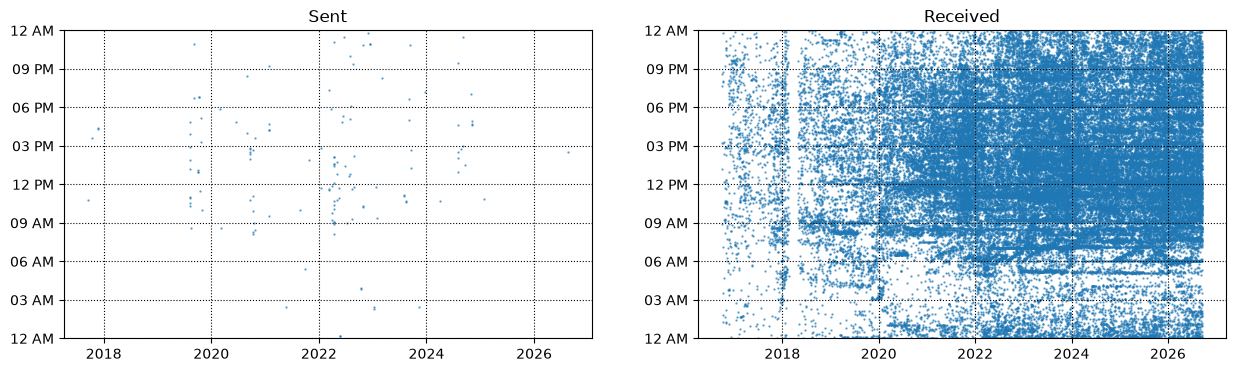

In [31]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 4))

plot_todo_vs_year(sent, ax[0], title='Sent')
plot_todo_vs_year(received, ax[1], title='Received')

## Average emails per day and hour

In [32]:
def plot_number_perday_per_year(df, ax, label=None, dt=0.3, **plot_kwargs):
    year = df[df['year'].notna()]['year'].values
    T = year.max() - year.min()
    bins = int(T / dt)
    weights = 1 / (np.ones_like(year) * dt * 365.25)
    ax.hist(year, bins=bins, weights=weights, label=label, **plot_kwargs);
    ax.grid(ls=':', color='k')

In [33]:
from scipy import ndimage

def plot_number_perdhour_per_year(df, ax, label=None, dt=1, smooth=False,
                      weight_fun=None, **plot_kwargs):

    tod = df[df['timeofday'].notna()]['timeofday'].values
    year = df[df['year'].notna()]['year'].values
    Ty = year.max() - year.min()
    T = tod.max() - tod.min()
    bins = int(T / dt)
    if weight_fun is None:
        weights = 1 / (np.ones_like(tod) * Ty * 365.25 / dt)
    else:
        weights = weight_fun(df)
    if smooth:
        hst, xedges = np.histogram(tod, bins=bins, weights=weights);
        x = np.delete(xedges, -1) + 0.5*(xedges[1] - xedges[0])
        hst = ndimage.gaussian_filter(hst, sigma=0.75)
        f = interp1d(x, hst, kind='cubic')
        x = np.linspace(x.min(), x.max(), 10000)
        hst = f(x)
        ax.plot(x, hst, label=label, **plot_kwargs)
    else:
        ax.hist(tod, bins=bins, weights=weights, label=label, **plot_kwargs);

    ax.grid(ls=':', color='k')
    orientation = plot_kwargs.get('orientation')
    if orientation is None or orientation == 'vertical':
        ax.set_xlim(0, 24)
        ax.xaxis.set_major_locator(MaxNLocator(8))
        ax.set_xticklabels([datetime.datetime.strptime(str(int(np.mod(ts, 24))), "%H").strftime("%I %p")
                            for ts in ax.get_xticks()]);
    elif orientation == 'horizontal':
        ax.set_ylim(0, 24)
        ax.yaxis.set_major_locator(MaxNLocator(8))
        ax.set_yticklabels([datetime.datetime.strptime(str(int(np.mod(ts, 24))), "%H").strftime("%I %p")
                            for ts in ax.get_yticks()]);


In [34]:
class TriplePlot:
  def __init__(self):
    gs = gridspec.GridSpec(6, 6)
    self.ax1 = plt.subplot(gs[2:6, :4])
    self.ax2 = plt.subplot(gs[2:6, 4:6], sharey=self.ax1)
    plt.setp(self.ax2.get_yticklabels(), visible=False);
    self.ax3 = plt.subplot(gs[:2, :4])  
    plt.setp(self.ax3.get_xticklabels(), visible=False);

  def plot(self, df, color='darkblue', alpha=0.8, markersize=0.5, yr_bin=0.1, hr_bin=0.5):
    plot_todo_vs_year(df, self.ax1, color=color, s=markersize)
    plot_number_perdhour_per_year(df, self.ax2, dt=hr_bin, color=color, alpha=alpha, orientation='horizontal')
    self.ax2.set_xlabel('Average emails per hour')
    plot_number_perday_per_year(df, self.ax3, dt=yr_bin, color=color, alpha=alpha)
    self.ax3.set_ylabel('Average emails per day')

/var/folders/xy/3wn_z4lx6ync0pcssbr80txm0000gn/T/ipykernel_38220/2157647245.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_yticklabels([datetime.datetime.strptime(str(int(np.mod(ts, 24))), "%H").strftime("%I %p") for ts in ax.get_yticks()]);
/var/folders/xy/3wn_z4lx6ync0pcssbr80txm0000gn/T/ipykernel_38220/346083762.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_yticklabels([datetime.datetime.strptime(str(int(np.mod(ts, 24))), "%H").strftime("%I %p")
/var/folders/xy/3wn_z4lx6ync0pcssbr80txm0000gn/T/ipykernel_38220/2157647245.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_yticklabels([datetime.date

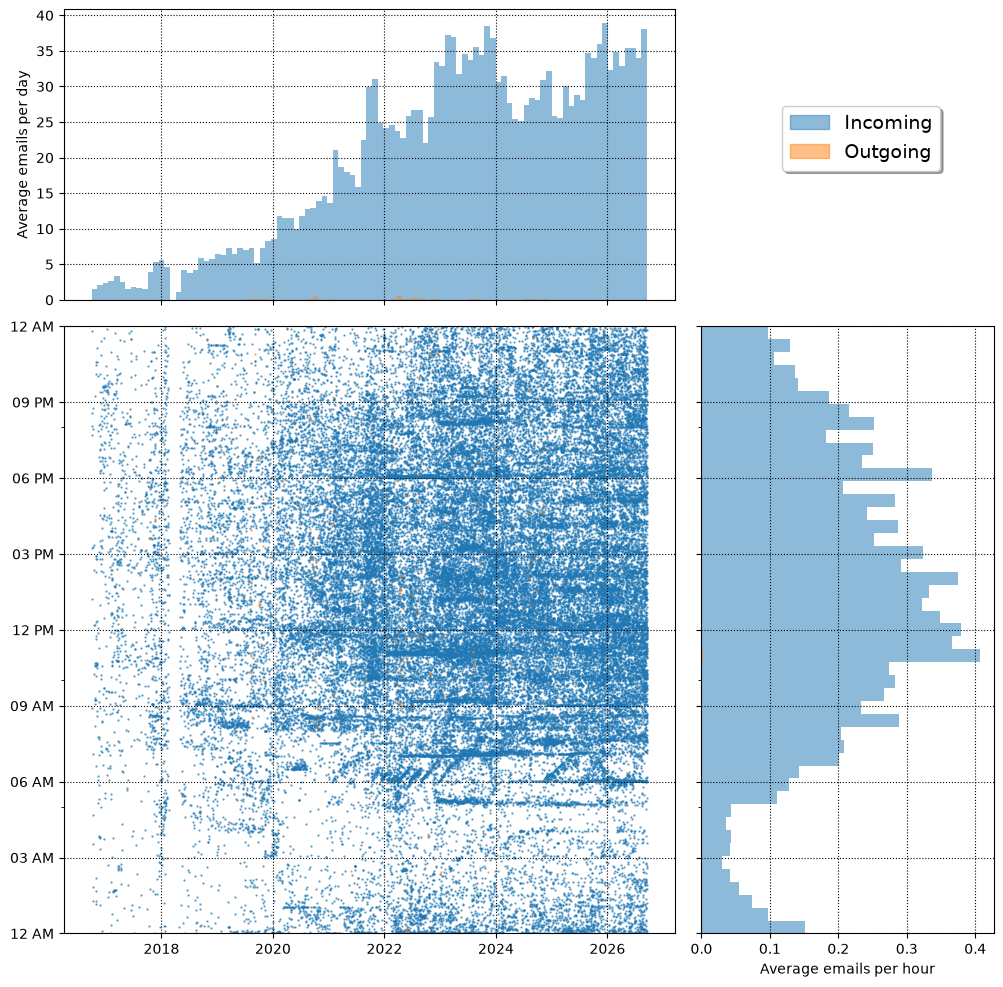

In [35]:
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

plt.figure(figsize=(12,12));
tpl = TriplePlot()

tpl.plot(received, color='C0', alpha=0.5)
tpl.plot(sent, color='C1', alpha=0.5)
p1 = mpatches.Patch(color='C0', label='Incoming', alpha=0.5)
p2 = mpatches.Patch(color='C1', label='Outgoing', alpha=0.5)
plt.legend(handles=[p1, p2], bbox_to_anchor=[1.45, 0.7], fontsize=14, shadow=True);

#The call tpl.plot(sent, ...) causes an error because I have no sent data in that timeframe

<Axes: xlabel='dayofweek'>

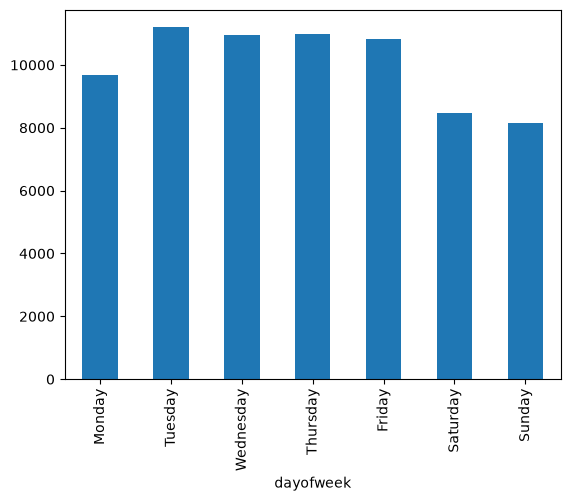

In [36]:
counts = dfs.dayofweek.value_counts(sort=False)
counts.plot(kind='bar')

In [37]:
addrs = received['from'].value_counts()

addrs[0:4]

from
noreply@r.groupon.com    2758
info@twitter.com         2621
cash@square.com          2602
webmaster@fastweb.com    2545
Name: count, dtype: int64

/var/folders/xy/3wn_z4lx6ync0pcssbr80txm0000gn/T/ipykernel_38220/2157647245.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_yticklabels([datetime.datetime.strptime(str(int(np.mod(ts, 24))), "%H").strftime("%I %p") for ts in ax.get_yticks()]);
/var/folders/xy/3wn_z4lx6ync0pcssbr80txm0000gn/T/ipykernel_38220/346083762.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_yticklabels([datetime.datetime.strptime(str(int(np.mod(ts, 24))), "%H").strftime("%I %p")
/var/folders/xy/3wn_z4lx6ync0pcssbr80txm0000gn/T/ipykernel_38220/2157647245.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_yticklabels([datetime.date

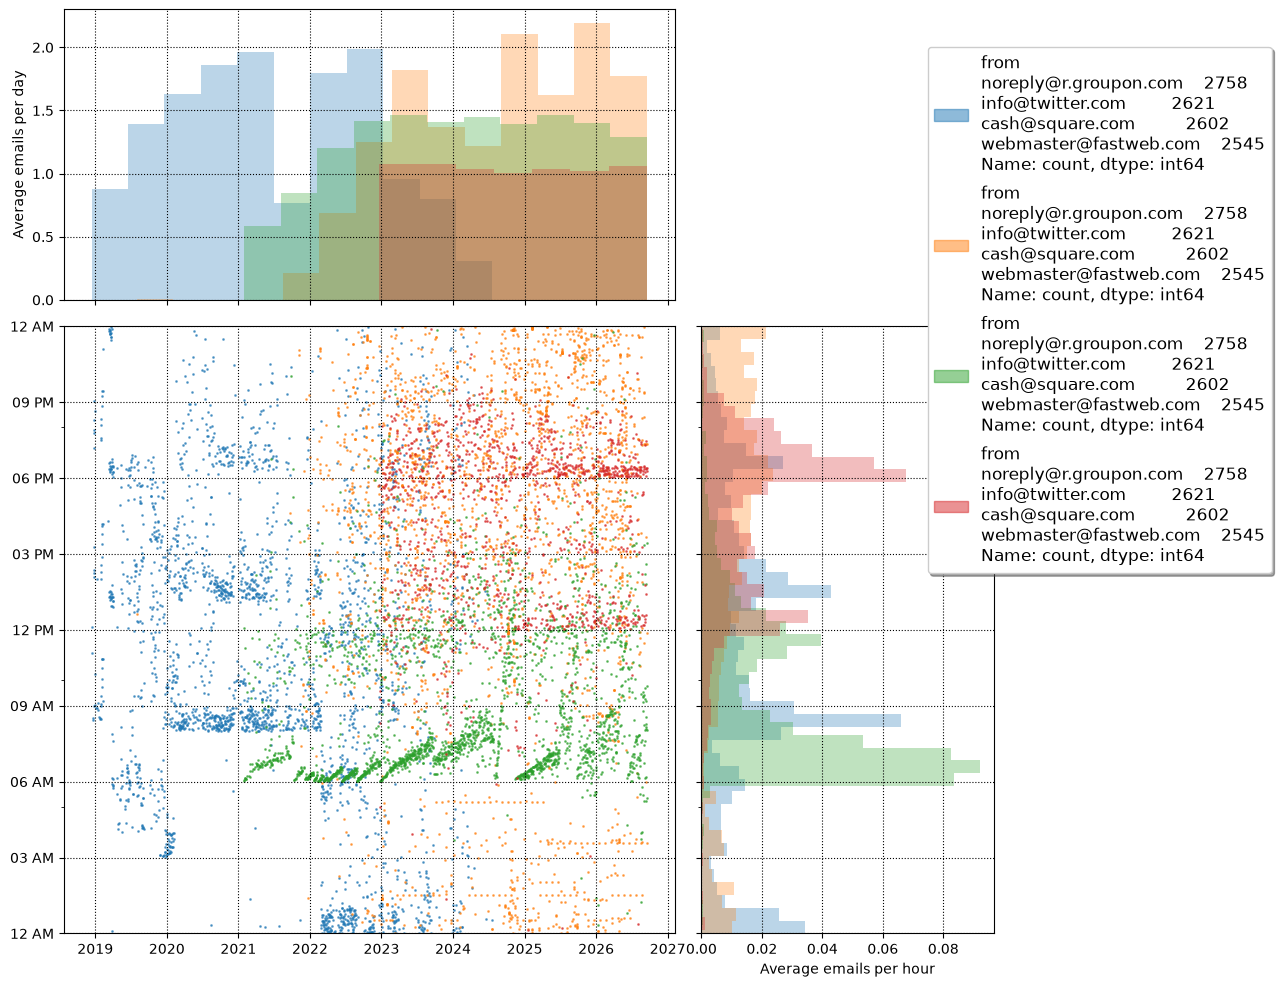

In [38]:
plt.figure(figsize=(12,12));

tpl = TriplePlot()

labels = []
colors = ['C{}'.format(ii) for ii in range(9)]
idx = np.array([1,2,3,7])
for ct, addr in enumerate(addrs.index[idx]):
    tpl.plot(dfs[dfs['from'] == addr], color=colors[ct], alpha=0.3, yr_bin=0.5, markersize=1.0)
    labels.append(mpatches.Patch(color=colors[ct], label=addrs[0:4], alpha=0.5))
plt.legend(handles=labels, bbox_to_anchor=[1.4, 0.9], fontsize=12, shadow=True);

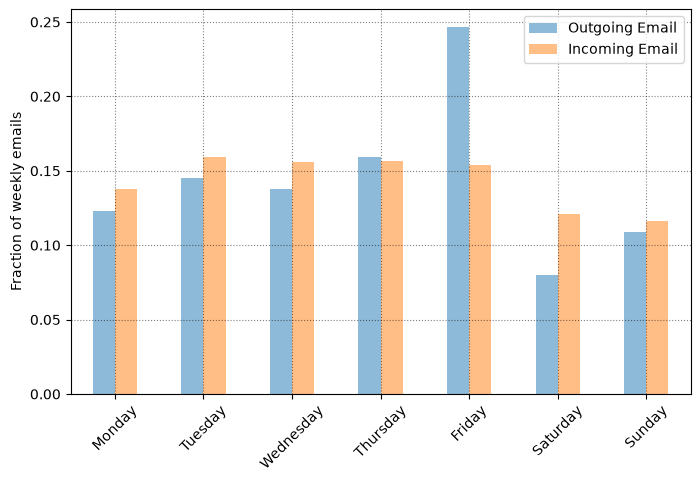

In [39]:
sdw = sent.groupby('dayofweek').size() / len(sent)
rdw = received.groupby('dayofweek').size() / len(received)

df_tmp = pd.DataFrame(data={'Outgoing Email': sdw, 'Incoming Email':rdw})
df_tmp.plot(kind='bar', rot=45, figsize=(8,5), alpha=0.5)
plt.xlabel('');
plt.ylabel('Fraction of weekly emails');
plt.grid(ls=':', color='k', alpha=0.5)

/var/folders/xy/3wn_z4lx6ync0pcssbr80txm0000gn/T/ipykernel_38220/346083762.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([datetime.datetime.strptime(str(int(np.mod(ts, 24))), "%H").strftime("%I %p")
/var/folders/xy/3wn_z4lx6ync0pcssbr80txm0000gn/T/ipykernel_38220/346083762.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([datetime.datetime.strptime(str(int(np.mod(ts, 24))), "%H").strftime("%I %p")
/var/folders/xy/3wn_z4lx6ync0pcssbr80txm0000gn/T/ipykernel_38220/346083762.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([datetime.datetime.strptime(str(int(np.mod(

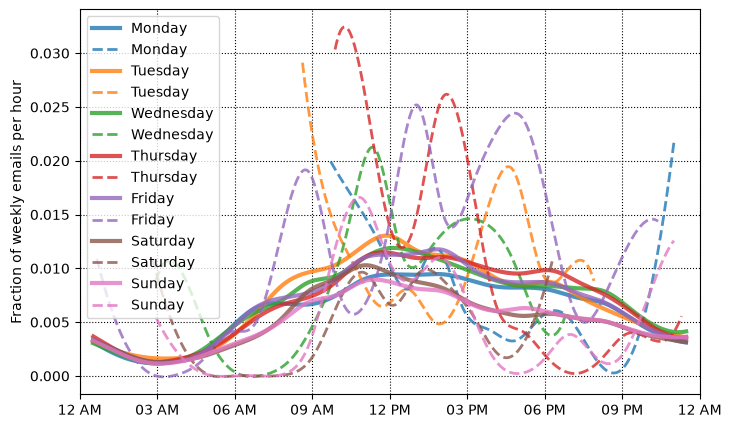

In [40]:
import scipy.ndimage
from scipy.interpolate import interp1d

plt.figure(figsize=(8,5))
ax = plt.subplot(111)
for ct, dow in enumerate(dfs.dayofweek.cat.categories):
    df_r = received[received['dayofweek']==dow]
    weights = np.ones(len(df_r)) / len(received)
    wfun = lambda x: weights
    plot_number_perdhour_per_year(df_r, ax, dt=1, smooth=True, color=f'C{ct}',
                      alpha=0.8, lw=3, label=dow, weight_fun=wfun)

    df_s = sent[sent['dayofweek']==dow]
    weights = np.ones(len(df_s)) / len(sent)
    wfun = lambda x: weights
    plot_number_perdhour_per_year(df_s, ax, dt=1, smooth=True, color=f'C{ct}',
                      alpha=0.8, lw=2, label=dow, ls='--', weight_fun=wfun)
ax.set_ylabel('Fraction of weekly emails per hour')
plt.legend(loc='upper left')

## Most frequently used words

In [41]:
from wordcloud import WordCloud 

df_no_arxiv = dfs[dfs['from'] != 'no-reply@arXiv.org']
text = ' '.join(map(str, sent['subject'].values))

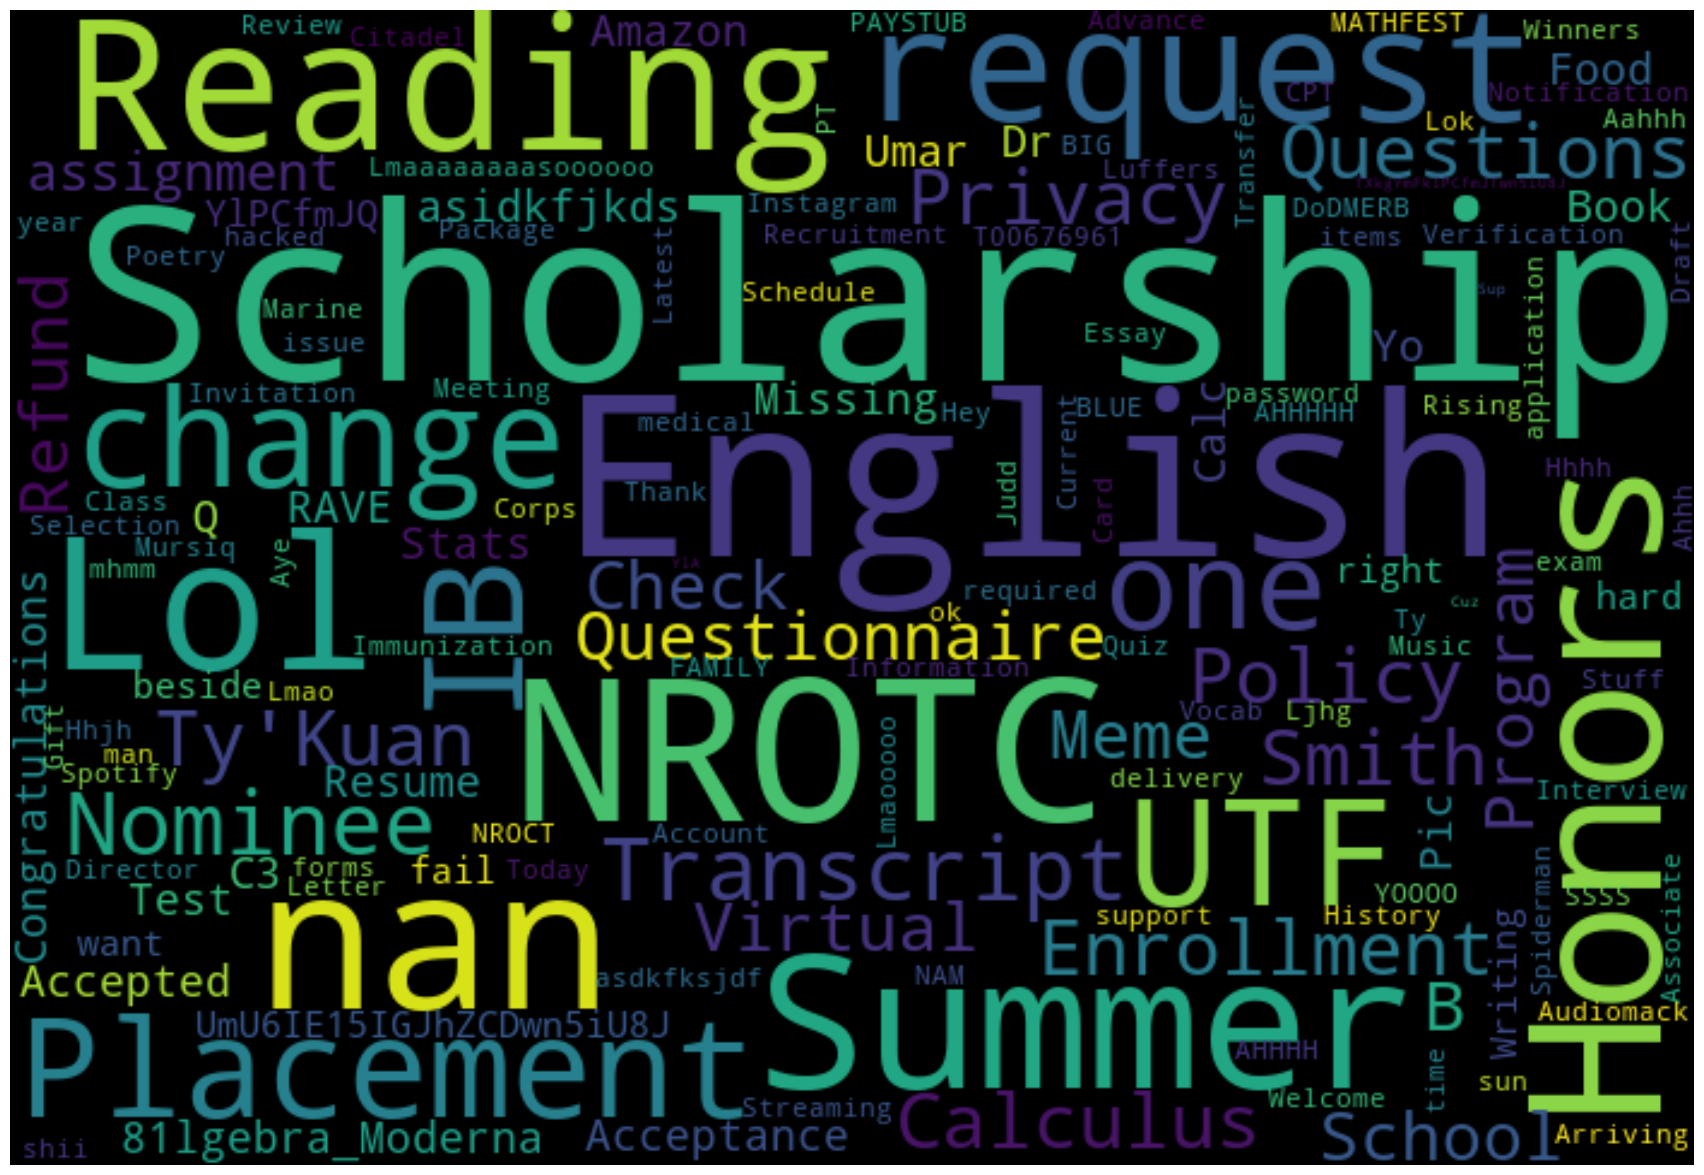

In [42]:
from wordcloud import WordCloud 

df_no_arxiv = dfs[dfs['from'] != 'no-reply@arXiv.org']
text = ' '.join(map(str, sent['subject'].values))
     

stopwords = ['Re', 'Fwd', '3A_']
wrd = WordCloud(width=700, height=480, margin=0, collocations=False)
for sw in stopwords:
    wrd.stopwords.add(sw)
wordcloud = wrd.generate(text)

plt.figure(figsize=(25,15))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.margins(x=0, y=0)